In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL, seasonal_decompose

In [2]:
pd.read_csv('https://raw.githubusercontent.com/rahulinchal/CSV-Files-/refs/heads/main/Data/AAPL.csv').to_csv('../Data/AppleStockPrice.csv',  index=False)

In [3]:
dat = pd.read_csv('../Data/AppleStockPrice.csv')
dat.head(5)

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [4]:
dat.columns = dat.columns.str.strip()

In [5]:
dat.rename(columns={
    'Close/Last': 'CL',
    'Volume': 'Vol'
}, inplace=True)

dat.head(5)

,Date,CL,Vol,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [6]:
dat['CL'] = dat['CL'].str.replace('$', '', regex=False)
dat['Open'] = dat['Open'].str.replace('$', '', regex=False)
dat['High'] = dat['High'].str.replace('$', '', regex=False)
dat['Low'] = dat['Low'].str.replace('$', '', regex=False)
dat['Date'] = pd.to_datetime(dat['Date'])
dat.head(5)

,Date,CL,Vol,Open,High,Low
0,2020-02-28,273.36,106721200,257.26,278.41,256.37
1,2020-02-27,273.52,80151380,281.1,286,272.96
2,2020-02-26,292.65,49678430,286.53,297.88,286.5
3,2020-02-25,288.08,57668360,300.95,302.53,286.13
4,2020-02-24,298.18,55548830,297.26,304.18,289.23


In [7]:
dat.info()
dat['CL'] = dat['CL'].astype('float64')
dat['Open'] = dat['Open'].astype('float64')
dat['High'] = dat['High'].astype('float64')
dat['Low'] = dat['Low'].astype('float64')
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2518 non-null   datetime64[ns]
 1   CL      2518 non-null   object        
 2   Vol     2518 non-null   int64         
 3   Open    2518 non-null   object        
 4   High    2518 non-null   object        
 5   Low     2518 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 118.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2518 non-null   datetime64[ns]
 1   CL      2518 non-null   float64       
 2   Vol     2518 non-null   int64         
 3   Open    2518 non-null   float64       
 4   High    2518 non-null   float64       
 5   Low     2518 non-null   float64       
dtypes: datet

In [8]:
dat_15_18 = dat[(dat['Date'].dt.year <= 2018) & (dat['Date'].dt.year >= 2015)]
print(dat_15_18['Date'].dt.date.min().strftime('%d/%m/%Y'), dat_15_18['Date'].dt.date.max().strftime('%d/%m/%Y'))
dat_15_18.head(5)

02/01/2015 31/12/2018


,Date,CL,Vol,Open,High,Low
292,2018-12-31,157.74,34499390,158.53,159.36,156.48
293,2018-12-28,156.23,41740600,157.50,158.52,154.55
294,2018-12-27,156.15,51608850,155.84,156.77,150.07
295,2018-12-26,157.17,58133850,148.30,157.23,146.72
296,2018-12-24,146.83,37169230,148.15,151.55,146.59


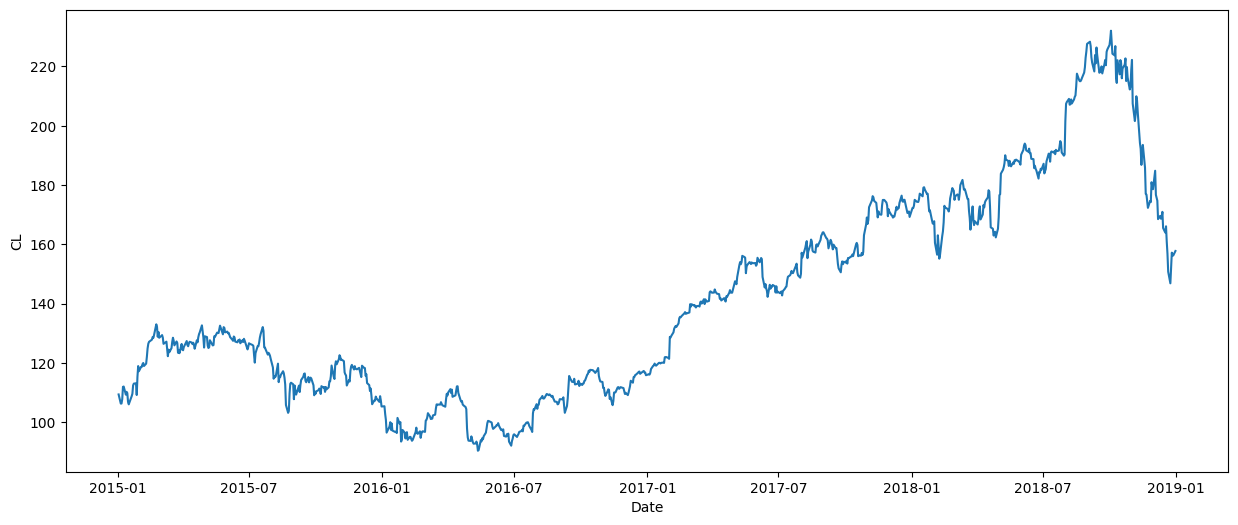

In [ ]:
plt.figure(figsize=(15,6))
sns.lineplot(data=dat_15_18, x='Date', y='CL')
plt.show()

In [ ]:
dat_15_18.groupby(by='Date')['CL'].mean()


Date
2015-01-02    109.33
2015-01-05    106.25
2015-01-06    106.26
2015-01-07    107.75
2015-01-08    111.89
               ...  
2018-12-24    146.83
2018-12-26    157.17
2018-12-27    156.15
2018-12-28    156.23
2018-12-31    157.74
Name: CL, Length: 1006, dtype: float64

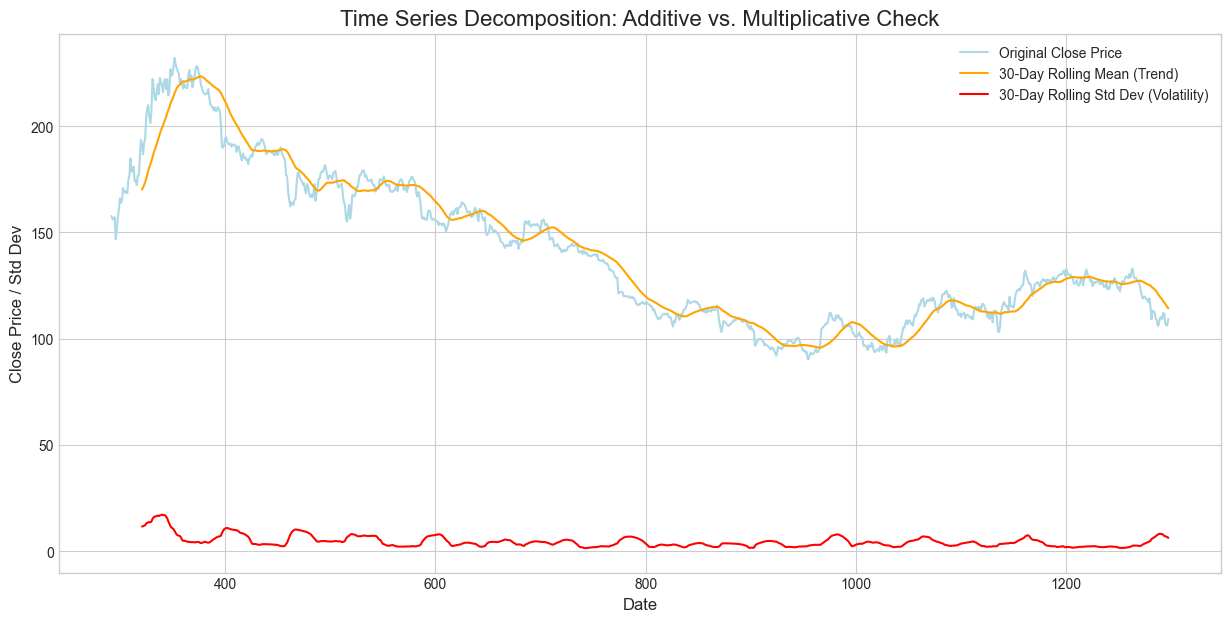

In [23]:
rolling_window = 30

# Calculate the rolling mean (trend)
rolling_mean = dat_15_18['CL'].rolling(window=rolling_window).mean()

# Calculate the rolling standard deviation (volatility)
rolling_std = dat_15_18['CL'].rolling(window=rolling_window).std()


# --- Plot the data and rolling statistics ---

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 7))

# Plot the original data
sns.lineplot(data=dat_15_18, x=dat_15_18.index, y='CL', label='Original Close Price', color='lightblue')

# Plot the rolling mean
sns.lineplot(x=rolling_mean.index, y=rolling_mean, label=f'{rolling_window}-Day Rolling Mean (Trend)', color='orange')

# Plot the rolling standard deviation
sns.lineplot(x=rolling_std.index, y=rolling_std, label=f'{rolling_window}-Day Rolling Std Dev (Volatility)', color='red')

plt.title('Time Series Decomposition: Additive vs. Multiplicative Check', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price / Std Dev', fontsize=12)
plt.legend()
plt.show()